# 数据集预处理
针对单个数据集进行严格的：
- 设置随机种子
- 样本筛选
- 细胞质控
- 去除环境污染（是否需要？）
- 保存质控后数据至'UC/scRNA-seq_data/03_qc_filtered'文件夹
- 批次效应查看
- 降维聚类结果
- 处理异常细胞群
- 区分主要谱系

# 文件说明
- **文件名**: 6_GSE125527_pbmc_qc.h5ad 
- **存放位置**: 坚果云  `UC/scRNA-seq_data/03_qc_filtered/`  
- **生成日期**: 2025-11-3  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/1.2_qc_filtered/6_GSE125527_pbmc.ipynb  
- **内容说明**: 完成了针对单个数据的预处理工作，包括样本排除、细胞质控，并查看了样本间的批次效应。  

In [1]:
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
import scanpy as sc
sc.settings.verbosity = 1
print(sc.__version__)

/home/future/miniconda3/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


1.11.4


## 读取数据
GSE125527_pbmc数据集：
- 血液组织 免疫细胞
- 7UC，8HC

In [5]:
adata = sc.read_h5ad('/Users/future/Nutstore Files/UC/scRNA-seq_data/02_sample_merge/6_GSE125527_pbmc.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 40860 × 9916
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'n_cells'
    uns: 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

In [7]:
adata.obs.head()

,n_genes,GSM_id,GSM,id,nUMIs,mito_perc,detected_genes,cell_complexity,passing_mt,passing_nUMIs,passing_ngenes,doublet_score,predicted_doublet
GSM3576411_HC31_AAACCTGAGACTGGGT-2,575,GSM3576411_HC31,GSM3576411,HC31,1076,0.000000,575,0.534387,True,True,True,0.081174,False
GSM3576411_HC31_AAACCTGTCCCTAATT-2,979,GSM3576411_HC31,GSM3576411,HC31,2161,0.000000,979,0.453031,True,True,True,0.046435,False
GSM3576411_HC31_AAACCTGTCTGCAAGT-2,1088,GSM3576411_HC31,GSM3576411,HC31,2767,0.000000,1088,0.393206,True,True,True,0.060938,False
GSM3576411_HC31_AAACCTGTCTGCTGTC-2,1164,GSM3576411_HC31,GSM3576411,HC31,3281,0.000305,1164,0.354770,True,True,True,0.160096,False
GSM3576411_HC31_AAACGGGAGACAAGCC-2,1512,GSM3576411_HC31,GSM3576411,HC31,4212,0.000237,1512,0.358974,True,True,True,0.049767,False


## 处理细胞标签及分组

In [8]:
# 提取分组信息
import pandas as pd
adata.obs['group'] = adata.obs['id'].str.extract(r'([A-Za-z]+)', expand=False)
print(adata.obs[['id', 'group']].head())

                                      id group
GSM3576411_HC31_AAACCTGAGACTGGGT-2  HC31    HC
GSM3576411_HC31_AAACCTGTCCCTAATT-2  HC31    HC
GSM3576411_HC31_AAACCTGTCTGCAAGT-2  HC31    HC
GSM3576411_HC31_AAACCTGTCTGCTGTC-2  HC31    HC
GSM3576411_HC31_AAACGGGAGACAAGCC-2  HC31    HC


`.obs`当中只保留GSM信息和分组信息

In [9]:
adata.obs.drop(columns=['GSM_id', 'id'], inplace=True)
print(adata.obs.head())

                                    n_genes         GSM  nUMIs  mito_perc  \
GSM3576411_HC31_AAACCTGAGACTGGGT-2      575  GSM3576411   1076   0.000000   
GSM3576411_HC31_AAACCTGTCCCTAATT-2      979  GSM3576411   2161   0.000000   
GSM3576411_HC31_AAACCTGTCTGCAAGT-2     1088  GSM3576411   2767   0.000000   
GSM3576411_HC31_AAACCTGTCTGCTGTC-2     1164  GSM3576411   3281   0.000305   
GSM3576411_HC31_AAACGGGAGACAAGCC-2     1512  GSM3576411   4212   0.000237   

                                    detected_genes  cell_complexity  \
GSM3576411_HC31_AAACCTGAGACTGGGT-2             575         0.534387   
GSM3576411_HC31_AAACCTGTCCCTAATT-2             979         0.453031   
GSM3576411_HC31_AAACCTGTCTGCAAGT-2            1088         0.393206   
GSM3576411_HC31_AAACCTGTCTGCTGTC-2            1164         0.354770   
GSM3576411_HC31_AAACGGGAGACAAGCC-2            1512         0.358974   

                                    passing_mt  passing_nUMIs  passing_ngenes  \
GSM3576411_HC31_AAACCTGAGACTG

In [10]:
adata.obs['group'].value_counts()

group
UC    24340
HC    16520
Name: count, dtype: int64

## 样本质量查看

In [11]:
adata.obs['GSM'].value_counts()

GSM
GSM3576418    3895
GSM3576415    3806
GSM3576412    3536
GSM3576422    3515
GSM3576416    3435
GSM3576417    3374
GSM3576413    3364
GSM3576419    3362
GSM3576414    3104
GSM3576425    2755
GSM3576420    2208
GSM3576411    1607
GSM3576421    1163
GSM3576424     896
GSM3576423     840
Name: count, dtype: int64

In [12]:
sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])

print(sample_quality_stats)

                n_genes                               nUMIs                    \
                   mean         std  min   max         mean          std  min   
GSM                                                                             
GSM3576411  1246.571251  547.688509  391  4747  3369.912259  2213.344784  580   
GSM3576412  1271.684672  441.235194  394  3703  3615.103224  1850.283311  691   
GSM3576413   899.140012  344.950485  397  3306  2067.266944  1096.655793  632   
GSM3576414   761.855026  285.048722  387  2262  1795.112436   962.906117  601   
GSM3576415  1062.875985  389.296536  392  3322  3097.695481  1565.370635  681   
GSM3576416   609.698690  225.286177  382  2141  1402.740611   715.980541  594   
GSM3576417   741.594843  232.758478  389  2156  1639.242739   734.938016  567   
GSM3576418   731.240822  243.996036  340  2919  1479.425417   724.486019  560   
GSM3576419   785.349792  303.300106  385  3795  1686.219215   966.271353  541   
GSM3576420  1506.301178  607

/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_40970/2761774101.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_quality_stats = adata.obs.groupby('GSM')[['n_genes', 'nUMIs', 'mito_perc']].agg(['mean', 'std', 'min', 'max'])


## 细胞质控

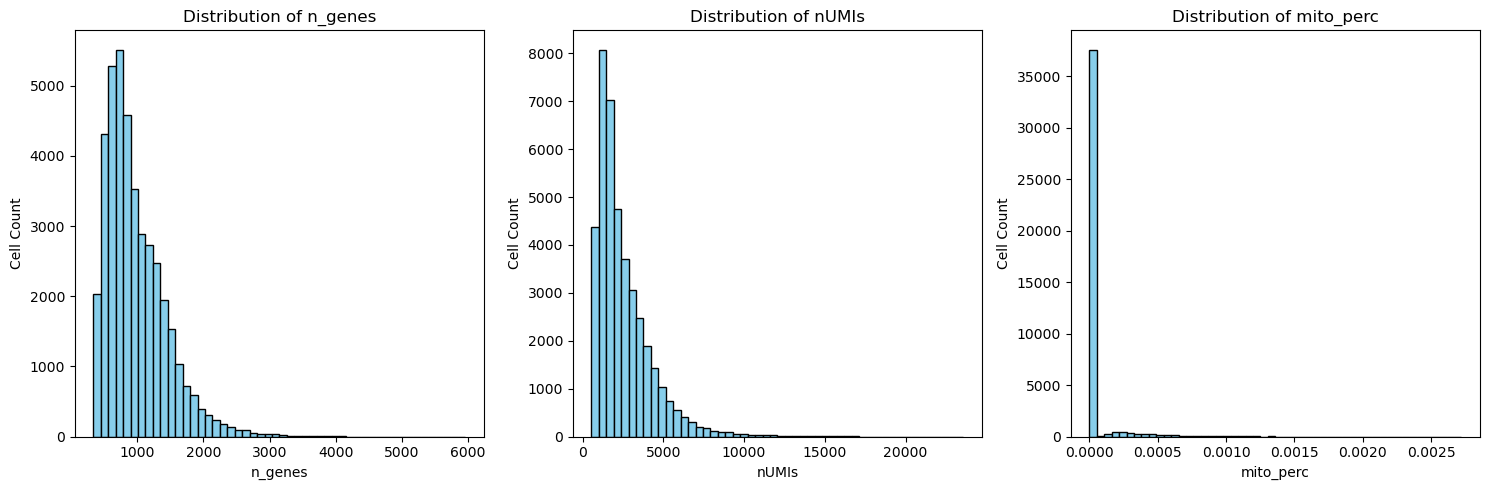

In [13]:
import matplotlib.pyplot as plt

# 选择要可视化的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 绘制各个指标的直方图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# 绘制每个质量控制指标的直方图
for i, metric in enumerate(qc_metrics):
    ax[i].hist(adata.obs[metric], bins=50, color='skyblue', edgecolor='black')
    ax[i].set_title(f'Distribution of {metric}')
    ax[i].set_xlabel(metric)
    ax[i].set_ylabel('Cell Count')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/var/folders/n6/ygb1nb55663b38zz1rbjx5lm0000gn/T/ipykernel_40970/2077234365.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(labels, rotation=45, ha='right')
/Users/future/miniconda3/envs/scanpy/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:840: FutureWarning: 

Passing `palette` without assigning `hue` is depreca

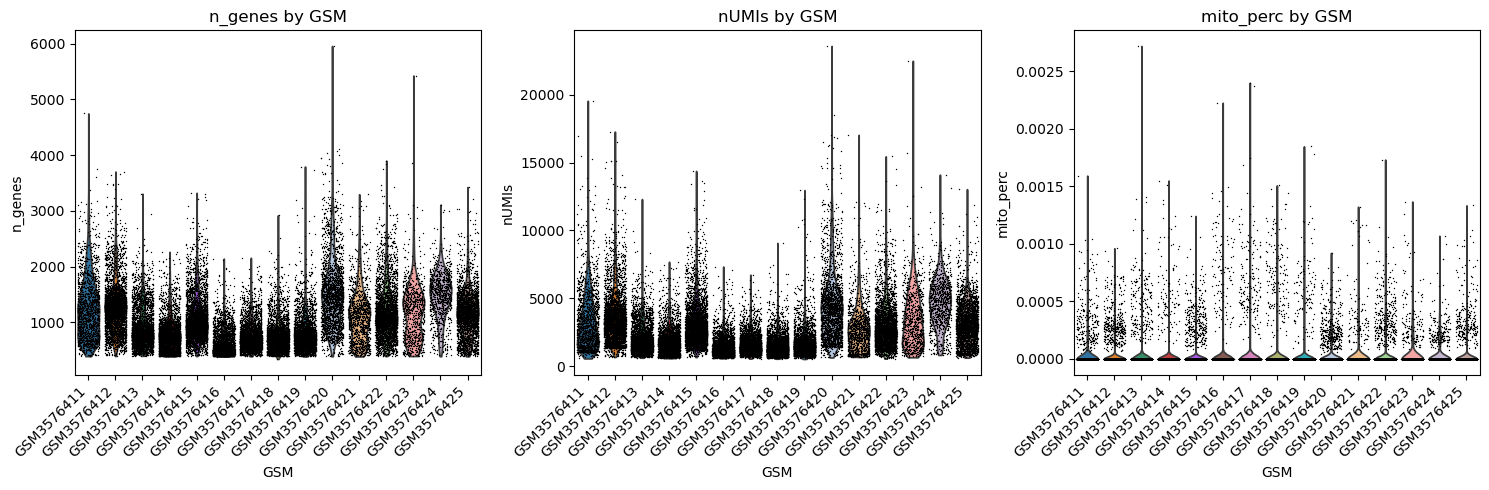

In [14]:
# 设置绘图风格
sc.settings.verbosity = 0  # 简化日志输出

# 选择要绘制的小提琴图的质量控制指标
qc_metrics = ['n_genes', 'nUMIs', 'mito_perc']

# 按照样本（GSM）绘制小提琴图
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(qc_metrics):
    sc.pl.violin(adata, keys=metric, groupby='GSM', ax=ax[i], stripplot=True, jitter=0.4, show=False)
    ax[i].set_title(f'{metric} by GSM')
    ax[i].set_ylabel(f'{metric}')
    
    # 获取当前的x轴标签
    labels = ax[i].get_xticklabels()
    # 旋转标签并调整对齐方式（末尾对齐）
    ax[i].set_xticklabels(labels, rotation=45, ha='right')

# 调整布局，避免重叠
plt.tight_layout()
plt.show()


### 严格细胞质控标准
- min_genes = 200          # 最少基因数
- max_genes = 4000         # 最多基因数
- min_umis = 500           # 最少UMI数量
- max_umis = 20000         # 最多UMI数量
- max_mito_perc = 10       # 线粒体基因百分比最大值

In [15]:
# 设置阈值
min_genes = 200          # 最少基因数
max_genes = 6000         # 最多基因数
min_umis = 500           # 最少UMI数量
max_umis = 20000        # 最多UMI数量
max_mito_perc = 0.1       # 线粒体基因百分比最大值

# 根据阈值进行过滤
adata = adata[(adata.obs['n_genes'] > min_genes) & 
              (adata.obs['n_genes'] < max_genes) &
              (adata.obs['nUMIs'] > min_umis) &
              (adata.obs['nUMIs'] < max_umis) &
              (adata.obs['mito_perc'] < max_mito_perc), :]

# 输出过滤后的细胞数
print(f'Number of cells after filtering: {adata.n_obs}')

Number of cells after filtering: 40858


## 保存质控后数据


In [16]:
import os
output_dir = "/Users/future/Nutstore Files/UC/scRNA-seq_data/03_qc_filtered/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "6_GSE125527_pbmc_qc.h5ad"), compression='gzip')

In [7]:
adata = sc.read_h5ad("/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/03_qc_filtered/6_GSE125527_pbmc_qc.h5ad")
adata

AnnData object with n_obs × n_vars = 40858 × 9916
    obs: 'n_genes', 'GSM', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'group'
    var: 'mt', 'n_cells'
    uns: 'GSM_colors', 'REFERENCE_MANU', 'scrublet', 'status', 'status_args'

## 降维聚类

In [8]:
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
ov.settings.cpu_gpu_mixed_init()

🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU-GPU mixed mode activated


血液组织 免疫细胞，所以选取1000个高变基因  
大致分别谱系，所以选取resolution=0.4

In [9]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=1000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.4)

Begin robust gene identification
After filtration, 9916/9916 genes are kept.     Among 9916 genes, 9916 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKV4.1', 'IGKV1.5', 'IGKV3.20', 'IGHV5.51', 'IGLV2.14', 'IGLV2.11', 'IGLV3.1']
    finished (0:00:02)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 26.67728614807129 seconds.
End of size normalization: shiftlog and HVGs selection pearson
🚀 Using GPU to calculate PCA...
NVIDI

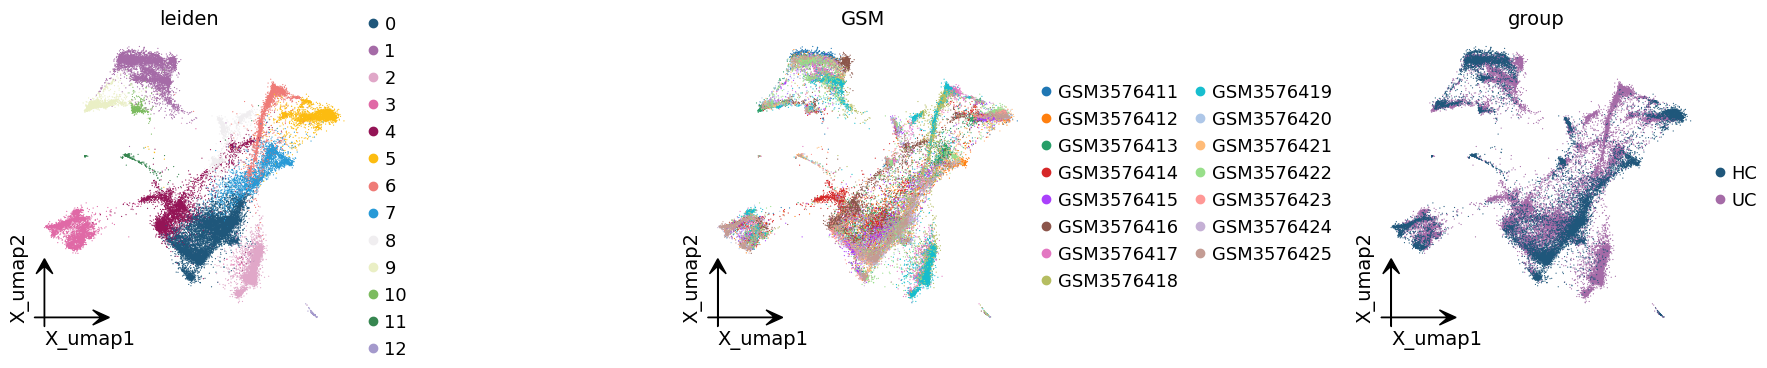

In [11]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.8)

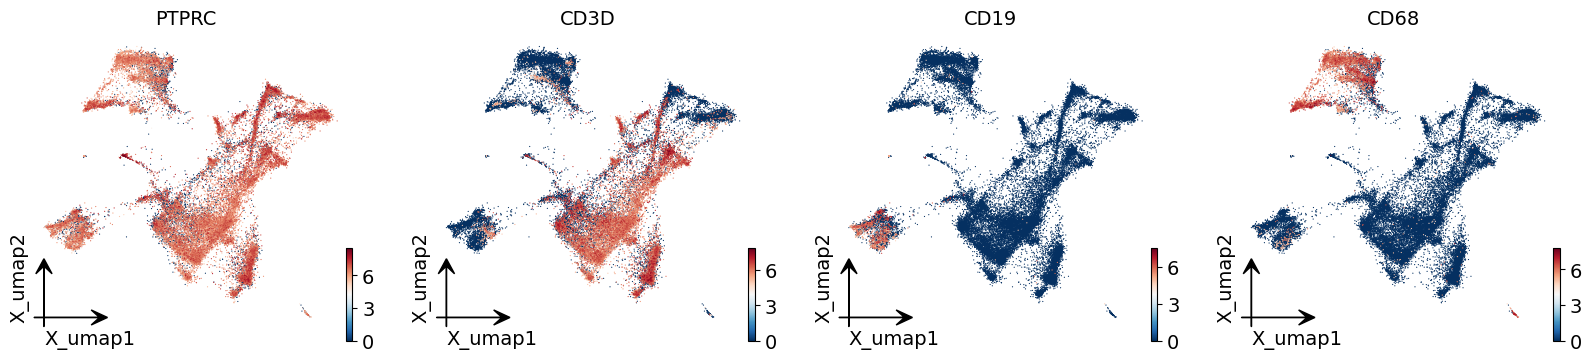

In [12]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## 去除批次效应
按样本去除批次，看看是否效果会更好

使用`harmony`

In [13]:
ov.single.batch_correction(adata,
                           batch_key='GSM', # 去批次分组标签
                           methods='harmony',
                           n_pcs=50)
                           
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='X_harmony')

ov.pp.umap(adata)

ov.pp.leiden(adata,resolution=0.4)

...Begin using harmony to correct batch effect


2025-11-06 08:30:10,000 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-06 08:30:14,447 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-06 08:30:14,590 - harmonypy - INFO - Iteration 1 of 10
2025-11-06 08:30:21,245 - harmonypy - INFO - Iteration 2 of 10
2025-11-06 08:30:27,926 - harmonypy - INFO - Iteration 3 of 10
2025-11-06 08:30:34,649 - harmonypy - INFO - Iteration 4 of 10
2025-11-06 08:30:40,138 - harmonypy - INFO - Iteration 5 of 10
2025-11-06 08:30:44,332 - harmonypy - INFO - Iteration 6 of 10
2025-11-06 08:30:49,243 - harmonypy - INFO - Iteration 7 of 10
2025-11-06 08:30:55,437 - harmonypy - INFO - Iteration 8 of 10
2025-11-06 08:30:58,252 - harmonypy - INFO - Iteration 9 of 10
2025-11-06 08:31:00,998 - harmonypy - INFO - Iteration 10 of 10
2025-11-06 08:31:03,148 - harmonypy - INFO - Stopped before convergence


🖥️ Using Scanpy CPU to calculate neighbors...
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
🔍 [2025-11-06 08:31:05] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
nvidia-smi not available, using PyTorch CUDA info
📊 [CUDA 0] NVIDIA GeForce RTX 5060 Ti
    ------------------------------ 328/16310 MiB (2.0%)
    Allocated: 328 MiB, Cached: 372 MiB
computing UMAP🚀
    finished ✅: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)
✅ UMAP completed successfully.
🖥️ Using Scanpy CPU Leiden...
running Leiden clustering
    finished: found 10 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:15)


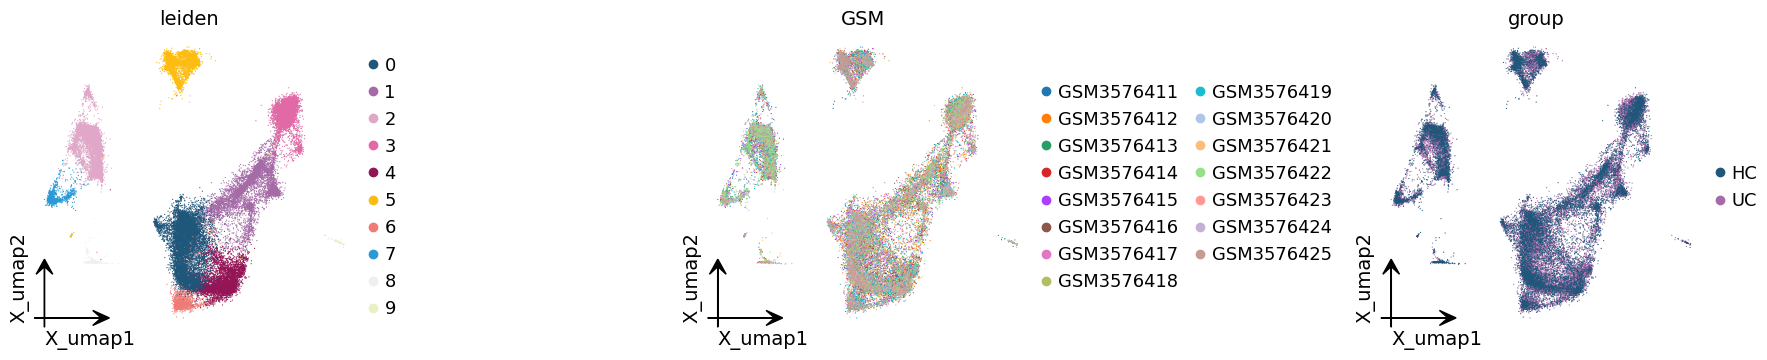

In [15]:
# 可视化查看去除批次效应后聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'GSM', 'group'],
                frameon='small',
                wspace=0.8)

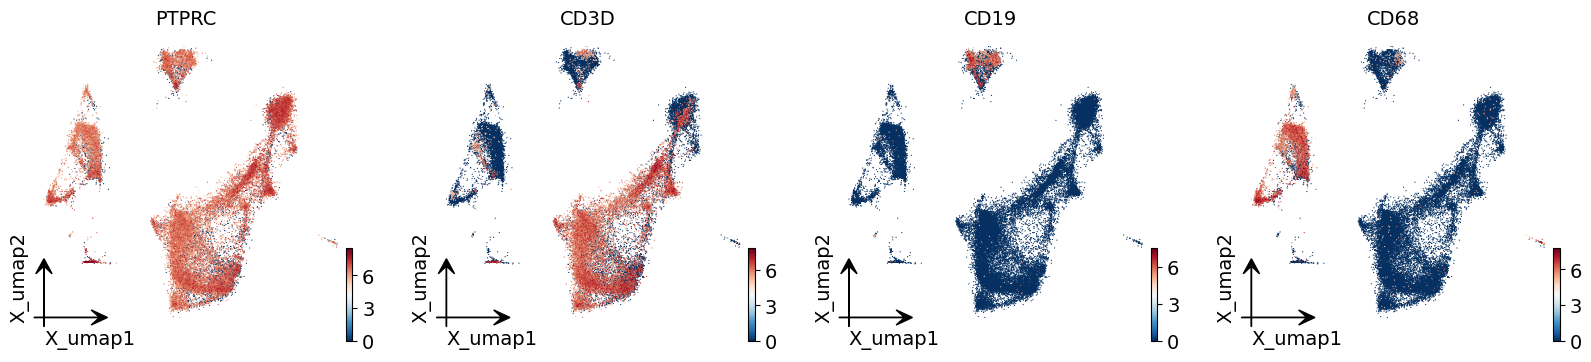

In [16]:
# 免疫谱系
ov.pl.embedding(adata,
                basis='X_umap',
                color=['PTPRC', 'CD3D', 'CD19', 'CD68'], 
                frameon='small')

## GPT自动注释

In [17]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:17)


{'0': ['LDHB',
  'MAL',
  'IL32',
  'LTB',
  'CD3E',
  'NOSIP',
  'CD3D',
  'IL7R',
  'NPM1',
  'SARAF'],
 '1': ['IL32',
  'CTSW',
  'CCL5',
  'DUSP2',
  'CD3E',
  'CST7',
  'GZMA',
  'GZMK',
  'NKG7',
  'GZMM'],
 '2': ['FCN1',
  'NEAT1',
  'S100A8',
  'LYZ',
  'FTH1',
  'FTL',
  'TYROBP',
  'GPX1',
  'CST3',
  'S100A9'],
 '3': ['CTSW',
  'CST7',
  'FGFBP2',
  'PRF1',
  'GNLY',
  'GZMA',
  'IFITM2',
  'NKG7',
  'HOPX',
  'GZMB'],
 '4': ['LTB', 'IL7R'],
 '5': ['HLA.DQB1',
  'CD37',
  'CD74',
  'HLA.DRB1',
  'HLA.DPB1',
  'MS4A1',
  'HLA.DQA1',
  'HLA.DRA',
  'HLA.DPA1',
  'CD79A'],
 '6': ['LDHB',
  'CD8B',
  'LINC02446',
  'CD3E',
  'NOSIP',
  'NPM1',
  'LEF1',
  'CD8A',
  'NELL2',
  'TCF7'],
 '7': ['PSAP',
  'SAT1',
  'COTL1',
  'LST1',
  'AIF1',
  'FTH1',
  'SERPINA1',
  'FTL',
  'FCGR3A',
  'FCER1G'],
 '8': [],
 '9': ['IRF8',
  'TCF4',
  'PLD4',
  'JCHAIN',
  'NPC2',
  'CCDC50',
  'IRF7',
  'C12orf75',
  'SEC61B',
  'ITM2C']}

In [ ]:
os.environ['AGI_API_KEY'] = 'sk-b54d8fd2ec144ce78b32602024fba248'
result = ov.single.gptcelltype(all_markers,
                               tissuename='pbmc',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.


In [ ]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

In [ ]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [ ]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)